# O Impacto da Escala no Operador Densidade de Probabilidades em um Classificador Quântico

## Executa Classificador

In [1]:
import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def executaclassificador(x,w):
  n = len(x)

  #from sympy.physics.matrices import msigma(indice)

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*np.diag(w)

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

#Calculo o vetor de pesos como médias dos array de entrada
def pesos_vetores(array):
  vetor_medias=np.zeros(len(array[0]))
  for i in range(len(array[0])):
    vetor_medias[i]=np.mean(array[:,i],dtype=np.float64)
  return vetor_medias

#Normalização dos vetores
def normalizacao(fe,array,peso_estatistico=True,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False):
  if peso_estatistico==True and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==False:
    array[:,0] = fe*((array[:,0]-np.min(array[:,0]))/(np.max(array[:,0])-np.min(array[:,0]))-1) # Normalizando os pesos estatísticos em [0,1]
    array[:,1] = fe*((array[:,1]-np.min(array[:,1]))/(np.max(array[:,1])-np.min(array[:,1]))-1)
    array[:,2] = fe*((array[:,2]-np.min(array[:,2]))/(np.max(array[:,2])-np.min(array[:,2]))-1)
    array[:,3] = fe*((array[:,3]-np.min(array[:,3]))/(np.max(array[:,3])-np.min(array[:,3]))-1)

  elif peso_estatistico==False and normalizacao_pelo_maximo==True and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==False:
    array[:,0] = fe*(array[:,0])/(np.max(array[:,0]))
    array[:,1] = fe*(array[:,1])/(np.max(array[:,1]))
    array[:,2] = fe*(array[:,2])/(np.max(array[:,2]))
    array[:,3] = fe*(array[:,3])/(np.max(array[:,3]))
  elif peso_estatistico==False and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==True and normalizacao_vetorial_coluna==False:
    for i in range(150):
      array[i]=fe*array[i]/np.linalg.norm(array[i])
  elif peso_estatistico==False and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==True:
    for i in range(4):
      array[:,i]=fe*array[:,i]/np.linalg.norm(array[:,i])
  else:
    raise Exception('Algo tá errado')

  return array

#Importando iris.data
from sklearn import datasets
import pandas as pd

# load iris dataset
iris = datasets.load_iris()
# Since this is a bunch, create a dataframe
iris_df=pd.DataFrame(iris.data)
iris_df['class']=iris.target

iris_df.columns=['Sepal Lenght', 'Sepal Width', 'Petal Lenght', 'Petal Width', 'class']
iris_df.dropna(how="all", inplace=True) # remove any empty lines

#selecting only first 4 columns as they are the independent(X) variable
# any kind of feature selection or correlation analysis should be first done on these
iris_X=iris_df.iloc[:,[0,1,2,3]]

#fator de escala
def pesos_normalizados(x):
  w1=pesos_vetores(x[:50])
  w2=pesos_vetores(x[50:100])
  w3=pesos_vetores(x[100:150])
  return w1,w2,w3


def classificador_nos_sistemas(vetor,w1,w2,w3,imprimir=False,imprimir_escolha=False):

  rho_cog_new1,se1=executaclassificador(vetor,w1)
  rho_cog_new2,se2=executaclassificador(vetor,w2)
  rho_cog_new3,se3=executaclassificador(vetor,w3)
  rho_comparativo=np.array([rho_cog_new1,rho_cog_new2,rho_cog_new3]) #Cria um array para fazer o comparativo da maior probabilidade do sistema

  if imprimir==True:
    print('Com os valores indicados')
    print("rho_cog_new1[0,0] = ",rho_cog_new1[0,0])
    print("rho_cog_new1[1,1] = ",rho_cog_new1[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new2[0,0] = ",rho_cog_new2[0,0])
    print("rho_cog_new2[1,1] = ",rho_cog_new2[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new3[0,0] = ",rho_cog_new3[0,0])
    print("rho_cog_new3[1,1] = ",rho_cog_new3[1,1],'\n')

  if rho_cog_new1[1][1] >= rho_cog_new2[1][1] and rho_cog_new1[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=1
  elif rho_cog_new2[1][1] >= rho_cog_new1[1][1] and rho_cog_new2[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=2
  else:
    escolha_sistema=3

  #escolha_sistema=np.where(rho_comparativo==rho_comparativo.max())[0][0]+1
  if imprimir_escolha==True:
    print(f'É mais provável que o vetor escolhido seja do sistema {escolha_sistema}')
  return escolha_sistema,se1,se2,se3


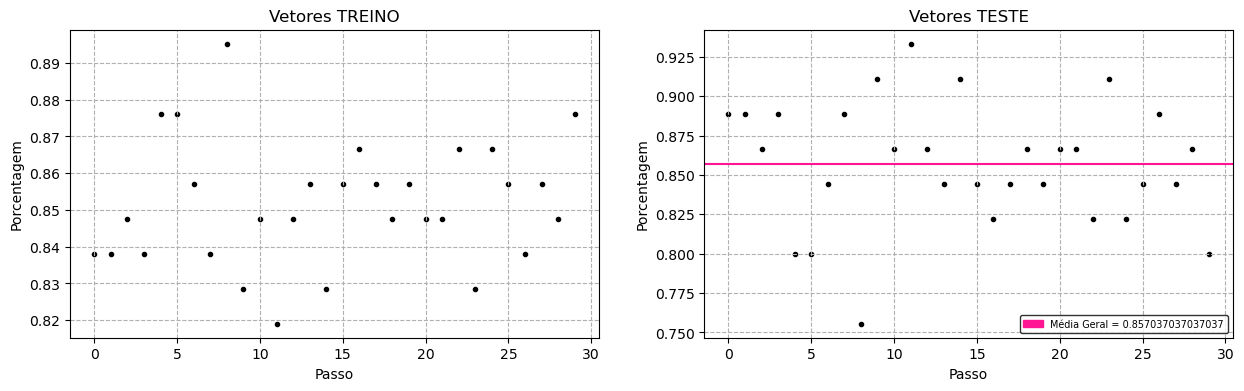

In [2]:
def vetores(start,stop): #Função para formar os vetores de treino e final
  #Mecanismo de Escolha Aleatória
  lista=[]
  for i in range(start,stop):
    lista.append(i) #Lista de índices
  lista=np.array(lista)

  reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

  vetores_treino=[]
  vetores_final=[]
  for i in range(35):
    vetores_treino.append(iris.data[int(reducao[i])])
    lista=lista[lista!=reducao[i]] #Filtro para array

  for i in range(15):
    vetores_final.append(iris.data[int(lista[i])])

  vetores_treino=np.array(vetores_treino)
  vetores_final=np.array(vetores_final)

  return vetores_treino,vetores_final,reducao

iris = datasets.load_iris()
normalizacao(0.7*np.pi,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=True,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False)
w1,w2,w3=pesos_normalizados(iris.data)

media_geral=[]
fig,ax=plt.subplots(1,2,figsize=(15,4))
for m in range(30):
  start=0
  stop=50
  vetores_treino=[]
  vetores_final=[]
  indices=[]
  for k in range(3):
    a,b,reducao=vetores(start,stop)
    for i in range(len(a)):
      vetores_treino.append(a[i])
      indices.append(reducao[i])
    for i in range(len(b)):
      vetores_final.append(b[i])
    start+=50
    stop+=50

  vetores_treino=np.array(vetores_treino)
  vetores_final=np.array(vetores_final)

  Nin=0
  for i in range(len(vetores_treino)):
    escolha_sistema,se1,se2,se3=classificador_nos_sistemas(vetores_treino[i],w1,w2,w3)
    if i<35:
      if escolha_sistema==1:
        Nin+=1
    if 35<=i and i<70:
      if escolha_sistema==2:
        Nin+=1
    if 70<=i and i<105:
      if escolha_sistema==3:
        Nin+=1

  percentual_treino=Nin/105
  ax[0].scatter(m,percentual_treino,color='k',marker='.')
  ax[0].set_xlabel('Passo')
  ax[0].set_ylabel('Porcentagem')
  ax[0].grid(ls='--')
  ax[0].title.set_text('Vetores TREINO')

  Nin=0
  for i in range(len(vetores_final)):
    escolha_sistema,se1,se2,se3=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
    if i<15:
      if escolha_sistema==1:
        Nin+=1
    if 15<=i and i<30:
      if escolha_sistema==2:
        Nin+=1
    if 30<=i and i<45:
      if escolha_sistema==3:
        Nin+=1

  percentual=Nin/45
  media_geral.append(percentual)
  ax[1].scatter(m,percentual,color='k',marker='.')
  ax[1].set_xlabel('Passo')
  ax[1].set_ylabel('Porcentagem')
  ax[1].grid(ls='--')
  ax[1].title.set_text('Vetores TESTE')
media_geral=np.mean(np.array(media_geral))
ax[1].axhline(media_geral,color='deeppink')
mg=mpatches.Patch(color='deeppink',label=f'Média Geral = {media_geral}')
ax[1].legend(handles=[mg], loc='lower right',fontsize='x-small',edgecolor='black')
fig.savefig('duo.png')
plt.show()

$\cdot$ O classificador se mostra simétrico para o sinal dos valores de escala


$\cdot$ A matriz $\mathcal{I}$ não parece interferir significativamente na precisão do modelo, porém interfere na localização do ponto de máximo global

$\cdot\cdot$ A precisão no modelo com o peso estatistico parece ter aumentado

## Peso Estatístico

                                           Porcentagem
Fator de Escala[0] = 0.0                      0.333333
Fator de Escala[1] = 0.5209676259721767       0.324444
Fator de Escala[2] = 1.0419352519443534       0.357778
Fator de Escala[3] = 1.5629028779165302       0.490000
Fator de Escala[4] = 2.083870503888707        0.295556
...                                                ...
Fator de Escala[195] = 101.58868706457446     0.247778
Fator de Escala[196] = 102.10965469054663     0.408889
Fator de Escala[197] = 102.63062231651881     0.371111
Fator de Escala[198] = 103.151589942491       0.400000
Fator de Escala[199] = 103.67255756846318     0.196667

[200 rows x 1 columns]


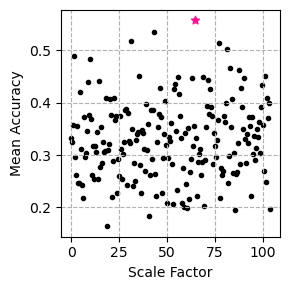

In [3]:
#@title fator_de_escala + Peso Estatístico

fator_de_escala=np.pi*np.linspace(0,33,200,endpoint=True) #O classifica

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15):
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=True,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20):
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema,se1,se2,se3=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(3,3))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
ax.set_xlabel('Scale Factor')
ax.set_ylabel('Mean Accuracy')
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
"""mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: [0,1], peso(MÁX)=1 e peso(MÍN)=1')"""
plt.tight_layout()
fig.savefig('min-max.png')
plt.show()



$\cdot$ Máximo com a Identidade:

$\cdot$ Máximo sem a Identidade: $\approx$ 0.747*$\pi$

## Normalização pelo Máximo

                                           Porcentagem
Fator de Escala[0] = 0.0                      0.333333
Fator de Escala[1] = 0.5209676259721767       0.333333
Fator de Escala[2] = 1.0419352519443534       0.333333
Fator de Escala[3] = 1.5629028779165302       0.600000
Fator de Escala[4] = 2.083870503888707        0.780000
...                                                ...
Fator de Escala[195] = 101.58868706457446     0.292222
Fator de Escala[196] = 102.10965469054663     0.338889
Fator de Escala[197] = 102.63062231651881     0.356667
Fator de Escala[198] = 103.151589942491       0.277778
Fator de Escala[199] = 103.67255756846318     0.526667

[200 rows x 1 columns]


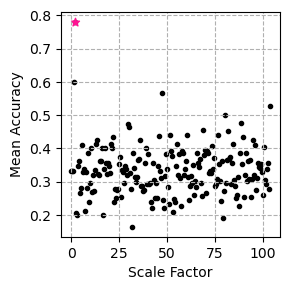

In [5]:
#@title fator_de_escala + Normalização pelo Máximo

fator_de_escala=np.pi*np.linspace(0,33,200,endpoint=True)

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15): #Loop para os vetores de teste
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=True,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20): #Loop para a média
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema,se1,se2,se3=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(3,3))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
ax.set_xlabel('Scale Factor')
ax.set_ylabel('Mean Accuracy')
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
"""mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: ]0,1], peso(MÁX)=1')"""
plt.tight_layout()
fig.savefig('abs-max.png')
plt.show()



$\cdot$ Máximo com a Identidade:

$\cdot$ Máximo sem a Identidade: $\approx$ 0.686*$\pi$

## Normalização pela linha

                                           Porcentagem
Fator de Escala[0] = 0.0                      0.333333
Fator de Escala[1] = 0.5209676259721767       0.000000
Fator de Escala[2] = 1.0419352519443534       0.037778
Fator de Escala[3] = 1.5629028779165302       0.335556
Fator de Escala[4] = 2.083870503888707        0.666667
...                                                ...
Fator de Escala[195] = 101.58868706457446     0.310000
Fator de Escala[196] = 102.10965469054663     0.244444
Fator de Escala[197] = 102.63062231651881     0.337778
Fator de Escala[198] = 103.151589942491       0.385556
Fator de Escala[199] = 103.67255756846318     0.323333

[200 rows x 1 columns]


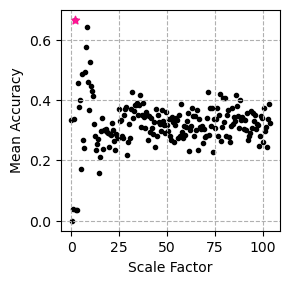

In [6]:
#@title fator_de_escala=np.pi + Normalização pela linha

fator_de_escala=np.pi*np.linspace(0,33,200,endpoint=True)

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15):
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=True,normalizacao_vetorial_coluna=False)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20):
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema,se1,se2,se3=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(3,3))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
ax.set_xlabel('Scale Factor')
ax.set_ylabel('Mean Accuracy')
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
"""mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: Vetorial Linha')"""
plt.tight_layout()
fig.savefig('vec-line.png')
plt.show()



$\cdot$ Máximo com a Identidade:

$\cdot$ Máximo sem a Identidade: $\approx$ 0.747*$\pi$

## Normalização pela coluna

In [7]:
#@title fator_de_escala=np.pi + Normalização pela coluna

fator_de_escala=np.pi*np.linspace(0,33,200,endpoint=True)

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15):
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=True)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20):
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema,se1,se2,se3=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(3,3))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
ax.set_xlabel('Scale Factor')
ax.set_ylabel('Mean Accuracy')
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
"""mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: Vetorial Coluna')"""
plt.tight_layout()
fig.savefig('vec-column.png')
plt.show()

